# Ensemble evaluation for long runs

This notebook evaluates and visualizes long settings ensemble runs across multiple parameterization strategies.

## Parameterization Methods

### Polynomial Baselines
- Deterministic polynomial parameterization
- Stochastic polynomial parameterization with AR(1) noise

### Bayesian Method
- Bayesian polynomial parameterization

### Flow-Based Parameterizations
- **Flow**: standard normalizing flow with Gaussian base distribution
- **AR(1) Base Flow**: normalizing flow with AR(1) base distribution
- **Forcing flow**: conditioning includes external forcing
- **Tail flow**: normalizing flow with flexible tails (Hickling and Prangle, 2025: https://openreview.net/forum?id=Z6RsbHAJk5)  
- **History flow**: conditioning includes state history
  

Each flow-based model is run with:
- white noise
- AR(1) noise

## Reference Simulation

All ensemble results are compared against a fully resolved Lorenz–96 (L96) ensemble simulation, which serves as the reference benchmark.

In [1]:
%autoreload

In [2]:
import sys
from pathlib import Path

# resolve project root (two levels up from this notebook)
PROJECT_ROOT = Path.cwd().resolve().parents[1]

SRC_DIR = PROJECT_ROOT / "src"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for p in (SRC_DIR, NOTEBOOKS_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

In [4]:
import gc
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.lines import Line2D

from ensemble.storage import (
    load_output_gcm_ensemble,
    load_output_l96_ensemble,
)
from notebook_utils import generate_sweep_dict_list, revert_sweep_name, save_plot
from utils.config import ConfigGCM, ConfigL96
from utils.sweep_utils import get_sweep_name
from scipy.stats import ks_2samp


## Load data

In [5]:
results_dir = PROJECT_ROOT / "results"

gcm_dirs = [
    results_dir / "ensemble_gcm_baseline_det",
    results_dir / "ensemble_gcm_baseline_ar_p",
    results_dir / "ensemble_gcm_bayes",
    results_dir / "ensemble_gcm_flow",
    results_dir / "ensemble_gcm_ar_base_flow",
    results_dir / "ensemble_gcm_history_flow",
    results_dir / "ensemble_gcm_forcing_flow",
    results_dir / "ensemble_gcm_tail_flow",
]
l96_dir = results_dir / "ensemble_l96"

n_init_states = 10
n_ens_members = 1
n_models = 1

output_subdir = ""

paper_figures_dir = (
    PROJECT_ROOT / "paper" / output_subdir / "figures" / "ensemble_evaluation" / "long"
)
paper_figures_dir.mkdir(parents=True, exist_ok=True)

output_dir = (
    PROJECT_ROOT
    / "notebooks"
    / "evaluation"
    / "output"
    / output_subdir
    / "ensemble_evaluation"
    / "long"
)
output_dir.mkdir(parents=True, exist_ok=True)


In [6]:
def load_yaml(file_path):
    with open(file_path, "r") as f:
        return yaml.safe_load(f)

### GCM data

In [7]:
data_dict = {}
t = None
DEFAULT_SWEEP_KEY = "default"

for gcm_d in gcm_dirs:
    print(f"Loading data from {gcm_d.name}...")

    long_dir = gcm_d / "long"

    sweep_path = long_dir / "sweep.yaml"
    sweep = load_yaml(sweep_path)

    data_dict[gcm_d.name] = {"sweep": sweep}

    for s in generate_sweep_dict_list(sweep):
        sweep_name = get_sweep_name(s)
        out_path = long_dir / sweep_name

        config_path = out_path / "config.yaml"
        config = ConfigGCM(config_path)

        assert config.n_init_states == n_init_states
        assert config.n_ens_members == n_ens_members
        assert config.n_models == n_models
        assert config.init_states_type == "perfect"

        seeds = out_path / "seeds" / "seeds.npy"
        if seeds.exists():
            seeds = np.load(seeds)
            assert seeds.size == n_init_states
            assert seeds.size == np.unique(seeds).size

        print(f"  Loading ensemble output for sweep: {sweep_name}...")

        x, t_curr = load_output_gcm_ensemble(
            config.output_dir(out_path), backend=config.load_backend
        )

        if t is None:
            t = t_curr
        else:
            assert np.allclose(t, t_curr)

        sweep_key = sweep_name if sweep_name != "" else DEFAULT_SWEEP_KEY
        data_dict[gcm_d.name][sweep_key] = x

print("Done.")

Loading data from ensemble_gcm_baseline_det...
  Loading ensemble output for sweep: ...
Loading data from ensemble_gcm_baseline_ar_p...
  Loading ensemble output for sweep: ...
Loading data from ensemble_gcm_bayes...
  Loading ensemble output for sweep: ...
Loading data from ensemble_gcm_flow...
  Loading ensemble output for sweep: noise_type_white-ar_order_0...
  Loading ensemble output for sweep: noise_type_ar_p-ar_order_1...
Loading data from ensemble_gcm_ar_base_flow...
  Loading ensemble output for sweep: noise_type_white-ar_order_0...
  Loading ensemble output for sweep: noise_type_ar_p-ar_order_1...
Loading data from ensemble_gcm_history_flow...
  Loading ensemble output for sweep: noise_type_white-ar_order_0-delta_t_1...
  Loading ensemble output for sweep: noise_type_white-ar_order_0-delta_t_2...
  Loading ensemble output for sweep: noise_type_ar_p-ar_order_1-delta_t_1...
  Loading ensemble output for sweep: noise_type_ar_p-ar_order_1-delta_t_2...
Loading data from ensemble_gc

### L96 data

In [8]:
long_dir = l96_dir / "long"

sweep_path = long_dir / "sweep.yaml"
sweep = load_yaml(sweep_path)

l96_data = {"sweep": sweep}

print(f"Loading data from {l96_dir.name}...")

for s in generate_sweep_dict_list(sweep):
    sweep_name = get_sweep_name(s)
    out_path = long_dir / sweep_name

    config_path = out_path / "config.yaml"
    config = ConfigL96(config_path, eval_mode=True)

    assert config.n_init_states == n_init_states
    assert config.n_models == n_models
    assert config.n_ens_members == n_ens_members
    assert config.init_states_type == "perfect"

    print(f"  Loading L96 output for sweep: {sweep_name}...")

    x, t_curr = load_output_l96_ensemble(
        config.output_dir(out_path), load_y=False, backend=config.load_backend
    )

    if t is None:
        t = t_curr
    else:
        assert np.allclose(t, t_curr)

    sweep_key = sweep_name if sweep_name != "" else DEFAULT_SWEEP_KEY
    l96_data[sweep_key] = x

print("Done.")

Loading data from ensemble_l96...
  Loading L96 output for sweep: ...
Done.


## Create dataframe for plotting

In [9]:
def _parse_model_meta_from_cfg_key(cfg_key, sweep):
    """
    Parse meta data: for empty sweep dict, use fixed c,F and None noise params.
    Otherwise parse from cfg_key via revert_sweep_name(cfg_key, sweep).
    """
    if sweep == {}:
        return dict(c=10.0, F=20.0, noise_type=None, ar_order=None, delta_t=None)

    parsed = revert_sweep_name(cfg_key, sweep)
    noise_type = parsed.get("noise_type")
    ar_order = parsed.get("ar_order")
    ar_order = int(ar_order) if ar_order is not None else None
    delta_t = parsed.get("delta_t")
    delta_t = int(delta_t) if delta_t is not None else None
    return dict(
        c=10.0, F=20.0, noise_type=noise_type, ar_order=ar_order, delta_t=delta_t
    )


In [10]:
def dicts_to_df(data_dict: dict, truth_data, truth_name: str = "Truth"):
    """
    named_dicts: mapping like
      {
        "ensemble_gcm_baseline_det_climate": ensemble_gcm_baseline_det_climate,
        "ensemble_gcm_flow_climate": ensemble_gcm_flow_climate,
        "truth": truth_dict,
      }
    Each inner dict contains keys like 'config','sweep', plus sweep outputs.
    """
    rows = []

    data_dict[truth_name] = truth_data

    for source_name, d in data_dict.items():
        sweep = d["sweep"]

        for k, x in d.items():
            if k in ("sweep"):
                continue

            meta = _parse_model_meta_from_cfg_key(k, sweep)
            # in case of baseline_ar_p, if ar_order is not in sweep, set to 1 by default
            if "baseline_ar_p" in source_name and meta["ar_order"] is None:
                meta["ar_order"] = 1

            rows.append(
                {
                    "source": source_name,
                    **meta,
                    "x": x,
                }
            )

    df = pd.DataFrame(rows)

    return df

In [11]:
data_df = dicts_to_df(data_dict, l96_data, truth_name="Truth")

## Plot PDF

In [12]:
def _format_mmss(seconds):
    m, s = divmod(int(seconds), 60)
    return f"{m:02d}:{s:02d}"


def flatten_x(x):
    # unwrap object arrays
    if isinstance(x, np.ndarray) and x.dtype == object:
        x = x[0]

    # load zarr / xarray properly
    if hasattr(x, "values"):  # xarray
        x = x.values
    elif hasattr(x, "__array__"):  # zarr
        x = np.asarray(x)

    return x.ravel()

In [13]:
def precompute_pdf_histlines(
    df: pd.DataFrame,
    bins=120,  # int (#edges) or array-like edges
    data_range=None,  # (xmin, xmax) or None
):
    """
    Returns plot_df with precomputed line data:
      columns: source, label, noise_type, centers, counts
    centers/counts are numpy arrays.

    Notes:
    - Uses shared bin edges across the whole df when bins is an int.
    - Avoids concatenating x arrays (no duplication).
    """

    required = {"source", "noise_type", "ar_order", "delta_t", "x"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"df missing required columns: {sorted(missing)}")

    rows = []

    # Determine bin edges (shared across df)
    print("Determine global x_min, x_max...")
    if data_range is not None:
        xmin, xmax = float(data_range[0]), float(data_range[1])
    else:
        xmin = np.inf
        xmax = -np.inf
        # for x in df["x"].values:
        for _, r in df.iterrows():
            x_arr = flatten_x(r["x"])
            if x_arr.size == 0:
                continue
            xmin = min(xmin, np.nanmin(x_arr))
            xmax = max(xmax, np.nanmax(x_arr))

        if not np.isfinite(xmin) or not np.isfinite(xmax):
            raise ValueError("Could not determine data range from df['x']")

    bin_edges = np.linspace(xmin, xmax, int(bins))
    centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    # Compute densities per row
    for _, r in df.iterrows():
        print(
            f"Processing source: {r['source']}, noise_type: {r['noise_type']}, ar_order: {r['ar_order']}, delta_t: {r['delta_t']}"
        )
        x_arr = flatten_x(r["x"])
        x_arr = x_arr[np.isfinite(x_arr)]
        if x_arr.size == 0:
            continue

        counts, _ = np.histogram(x_arr, bins=bin_edges, density=True)

        rows.append(
            {
                "source": r["source"],
                "noise_type": r["noise_type"],
                "ar_order": r["ar_order"],
                "delta_t": r["delta_t"],
                "centers": centers,  # shared object reused
                "counts": counts,
            }
        )

    print("DONE")
    return pd.DataFrame(rows)

In [14]:
t0 = time.perf_counter()
plot_df = precompute_pdf_histlines(data_df, bins=120)
elapsed = time.perf_counter() - t0
print(f"\nPDFs done in {_format_mmss(elapsed)}")
gc.collect()

plot_df.to_parquet(output_dir / "precomputed_pdf_histlines.parquet")
print("\nSaved precomputed PDF histlines to parquet.")

Determine global x_min, x_max...
Processing source: ensemble_gcm_baseline_det, noise_type: None, ar_order: nan, delta_t: nan
Processing source: ensemble_gcm_baseline_ar_p, noise_type: None, ar_order: 1.0, delta_t: nan
Processing source: ensemble_gcm_bayes, noise_type: None, ar_order: nan, delta_t: nan
Processing source: ensemble_gcm_flow, noise_type: white, ar_order: 0.0, delta_t: nan
Processing source: ensemble_gcm_flow, noise_type: ar_p, ar_order: 1.0, delta_t: nan
Processing source: ensemble_gcm_ar_base_flow, noise_type: white, ar_order: 0.0, delta_t: nan
Processing source: ensemble_gcm_ar_base_flow, noise_type: ar_p, ar_order: 1.0, delta_t: nan
Processing source: ensemble_gcm_history_flow, noise_type: white, ar_order: 0.0, delta_t: 1.0
Processing source: ensemble_gcm_history_flow, noise_type: white, ar_order: 0.0, delta_t: 2.0
Processing source: ensemble_gcm_history_flow, noise_type: ar_p, ar_order: 1.0, delta_t: 1.0
Processing source: ensemble_gcm_history_flow, noise_type: ar_p, a

In [15]:
# # Load precomputed data from parquet
# plot_df = pd.read_parquet(output_dir / "precomputed_pdf_histlines.parquet")
# print("Loaded precomputed PDF histlines from parquet.")

In [16]:
plot_df.columns

Index(['source', 'noise_type', 'ar_order', 'delta_t', 'centers', 'counts'], dtype='object')

In [17]:
def _parse_noise_label(noise_type: str, ar_order: int):
    if noise_type is None and isinstance(ar_order, (int, float)):
        # Polynomial case
        return f"AR({int(ar_order)})"
    elif noise_type == "ar_p":
        return f"(AR({ar_order}))"
    elif noise_type == "white":
        return "(iid)"
    else:
        raise ValueError(f"Unknown noise_type: {noise_type}")


def parse_label(
    source_name: str, noise_type: str, ar_order: int, delta_t: int, line_breaks=False
):
    line_break = "\n" if line_breaks else " "
    if source_name == "Truth":
        return "Truth"
    if source_name.startswith("ensemble_gcm_baseline_det"):
        return f"Baseline{line_break}Deterministic"
    if source_name.startswith("ensemble_gcm_baseline_ar_p"):
        base_str = "Polynomial"
        return f"{base_str} + {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_bayes"):
        return "Bayesian"
    if source_name.startswith("ensemble_gcm_flow"):
        flow_str = "Flow"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_ar_base_flow"):
        flow_str = f"Base AR(1){line_break}Flow"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_history_flow"):
        if delta_t == 1:
            flow_str = f"History Flow{line_break}" + r"($\tau = 1$)"
        elif delta_t == 2:
            flow_str = f"History Flow{line_break}" + r"($\tau = 2$)"
        elif delta_t == 75:
            flow_str = f"History Flow{line_break}" + r"($\tau = 75$)"
        else:
            raise RuntimeError(f"Unexpected delta_t value: {delta_t}")
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_forcing_flow"):
        flow_str = f"Forcing Flow{line_break}"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_tail_flow"):
        flow_str = f"Tail Flow{line_break}"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"

    raise RuntimeError(f"Unexpected model type: {source_name}")


# Fixed ordering determines colors
MODEL_ORDER_DEFAULT = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-white",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_ar_base_flow-white",
    "ensemble_gcm_ar_base_flow-ar_p-1",
    "ensemble_gcm_forcing_flow-white",
    "ensemble_gcm_forcing_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-white",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_2-white",
    "ensemble_gcm_history_flow-delta_t_2-ar_p-1",
    "ensemble_gcm_tail_flow-white",
    "ensemble_gcm_tail_flow-ar_p-1",
]
MODEL_ORDER = MODEL_ORDER_DEFAULT


REDUCED_MODEL_ORDER = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-white",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-white",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_2-white",
    "ensemble_gcm_history_flow-delta_t_2-ar_p-1",
    "ensemble_gcm_ar_base_flow-white",
    "ensemble_gcm_ar_base_flow-ar_p-1",
    "ensemble_gcm_tail_flow-white",
    "ensemble_gcm_tail_flow-ar_p-1",
]


REDUCED_MODEL_ORDER_SELECTED = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_ar_base_flow-ar_p-1",
]


def model_order_to_query(order_key: str):
    """
    Parse MODEL_ORDER key into:
      (model, noise_type, ar_order, delta_t)

    Missing fields are returned as None.
    """
    model_base = order_key
    noise_type = None
    ar_order = None
    delta_t = None

    # delta_t (only for history_flow keys)
    m = re.search(r"-delta_t_(\d+)", model_base)
    if m:
        delta_t = int(m.group(1))
        model_base = model_base.replace(m.group(0), "")

    # flow/ar_p keys like "..._flow-ar_p-2"
    m = re.search(r"-ar_p-(\d+)", model_base)
    if m:
        ar_order = int(m.group(1))
        noise_type = "ar_p"
        model_base = model_base.replace(m.group(0), "")

    # baseline stochastic "..._baseline_ar_p-2"
    m = re.search(r"_ar_p-(\d+)", model_base)
    if m:
        ar_order = int(m.group(1))
        model_base = model_base.replace(m.group(0), "_ar_p")

    # white noise suffix
    if model_base.endswith("-white"):
        noise_type = "white"
        model_base = model_base.removesuffix("-white")
        ar_order = 0

    return model_base, noise_type, ar_order, delta_t


def select_pdf_rows_for_order_key(
    sub_models: pd.DataFrame, order_key: str
) -> pd.DataFrame:
    """
    Select rows from plot_df (models only, i.e. sub_models) that match an order_key from MODEL_ORDER,
    using model_order_to_query(order_key) = (model, noise_type, ar_order, delta_t).

    This assumes plot_df rows store:
      - source (string) == model_base
      - noise_type (string or None/NaN)
      - ar_order (numeric or None/NaN)
      - delta_t (numeric or None/NaN)
    """
    model, noise, ar_order, delta_t = model_order_to_query(order_key)

    m = sub_models

    # Compare None against NaN in dataframe
    if noise is None:
        noise_mask = m["noise_type"].isna()
    else:
        noise_mask = m["noise_type"] == noise

    if ar_order is None:
        ar_mask = m["ar_order"].isna()
    else:
        # ar_order column might be float because NaNs exist
        ar_mask = np.isclose(
            m["ar_order"].astype(float), float(ar_order), equal_nan=False
        )

    if delta_t is None:
        dt_mask = m["delta_t"].isna()
    else:
        dt_mask = np.isclose(
            m["delta_t"].astype(float), float(delta_t), equal_nan=False
        )

    mask = (m["source"].str.startswith(model)) & noise_mask & ar_mask & dt_mask
    return m.loc[mask].copy()

In [18]:
# Build colorblind palette once
_palette = sns.color_palette("colorblind", n_colors=len(MODEL_ORDER))
COLOR_MAP = dict(zip(MODEL_ORDER, _palette))

In [19]:
TEXT_WIDTH = 6.75
SLIDE_WIDTH = 13.333  # inches, standard 16:9 PPT
SLIDE_HEIGHT = 7.5


def scaled_fontsize(fontsize, figsize_width, which_base_width):
    if which_base_width == "text":
        base_width = TEXT_WIDTH * 1.2
        power = 1.0
    elif which_base_width == "column":
        base_width = TEXT_WIDTH
        power = 1.0
    elif which_base_width == "slide":
        base_width = SLIDE_WIDTH
        power = 0.6
    elif which_base_width == "slide_column":
        base_width = (
            8.0  # empirically chosen "half slide" width that looks good with power=0.6
        )
        power = 0.6
    else:
        raise ValueError(f"Unexpected which_base_width: {which_base_width}")

    return fontsize * (figsize_width / base_width) ** power


def get_plot_rc(base, figsize):
    if base == "column":
        rc = {
            "axes.titlesize": scaled_fontsize(11, figsize[0], base),
            "axes.labelsize": scaled_fontsize(9, figsize[0], base),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], base),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], base),
            "legend.fontsize": scaled_fontsize(10, figsize[0], base),
        }
    elif base == "text":
        rc = {
            "axes.titlesize": scaled_fontsize(11, figsize[0], base),
            "axes.labelsize": scaled_fontsize(9, figsize[0], base),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], base),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], base),
            "legend.fontsize": scaled_fontsize(10, figsize[0], base),
        }
    elif base == "slide":
        rc = {
            "axes.titlesize": scaled_fontsize(20, figsize[0], base),
            "axes.labelsize": scaled_fontsize(18, figsize[0], base),
            "xtick.labelsize": scaled_fontsize(16, figsize[0], base),
            "ytick.labelsize": scaled_fontsize(16, figsize[0], base),
            "legend.fontsize": scaled_fontsize(16, figsize[0], base),
            "axes.linewidth": 1.4,
            "xtick.major.width": 1.4,
            "ytick.major.width": 1.4,
            "xtick.major.size": 5.5,
            "ytick.major.size": 5.5,
        }
    else:
        raise ValueError(base)

    return rc


In [20]:
def plot_precomputed_pdf_histlines_grid(
    plot_df: pd.DataFrame,
    truth_source="truth",
    models_to_plot=None,
    ncols=3,
    grid_hspace=0.18,
    grid_wspace=0.12,
    left=0.07,
    right=0.98,
    bottom=0.08,
    top=0.93,
    figsize=(15, 10),
    bbox_to_anchor=(1.0, 0.99),
    legend_loc="upper left",
    legend_cols=1,
    title_line_breaks=False,
    which_base_width="text",
    show_legend=True,
    use_constrained_layout=True,
):
    """
    Grid plot: one panel per model (order_key in MODEL_ORDER).
    Each panel shows:
      - truth (black)
      - that model (colored)

    plot_df is expected to have at least:
      source, noise_type, ar_order, delta_t, centers, counts

    Labels are computed on the fly via parse_label(...).
    """
    sns.set_theme(
        style="white",
        rc=get_plot_rc(which_base_width, figsize),
    )
    lw = 1.6 if not which_base_width == "slide" else 2.2
    lw_truth = 2.2 if not which_base_width == "slide" else 3.0

    if plot_df.empty:
        raise ValueError("plot_df is empty")

    sub = plot_df.copy()

    # --- split truth vs models ---
    is_truth = sub["source"].astype(str).str.lower().eq(str(truth_source).lower())
    sub_truth = sub[is_truth].copy()
    sub_models = sub[~is_truth].copy()

    if sub_truth.empty:
        raise ValueError("No truth rows found (check truth_source / plot_df['source'])")
    if sub_models.empty:
        raise ValueError("No model rows found (plot_df only contains truth?)")

    # --- choose keys in MODEL_ORDER (optionally filtered) ---
    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)

    if not keys:
        raise ValueError("No matching models_to_plot found in MODEL_ORDER")

    # --- layout ---
    n = len(keys)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=use_constrained_layout,
    )
    if not use_constrained_layout:
        fig.subplots_adjust(
            left=left,
            right=right,
            bottom=bottom,
            top=top,
            wspace=grid_wspace,
            hspace=grid_hspace,
        )
    axes = np.atleast_2d(axes)

    # --- draw panels ---
    for idx, order_key in enumerate(keys):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        title = parse_label(
            model, noise, ar_order, delta_t, line_breaks=title_line_breaks
        )
        color = COLOR_MAP.get(order_key, "C0")

        # Truth in every panel (black, thick).
        # If multiple truth rows exist, plot them all; order isn't important now.
        for _, rr in sub_truth.iterrows():
            ax.plot(
                rr["centers"],
                rr["counts"],
                color="black",
                linewidth=lw_truth,
            )

        # Model rows for this panel
        sub_k = select_pdf_rows_for_order_key(sub_models, order_key)
        if not sub_k.empty:
            for _, rr in sub_k.iterrows():
                ax.plot(
                    rr["centers"],
                    rr["counts"],
                    color=color,
                    linewidth=lw,
                )

        ax.set_title(title)
        ax.tick_params(axis="both", bottom=True, left=True, length=3)

        # custom ticks
        ax.set_xticks([-10, -5, 0, 5, 10, 15, 20])
        ax.set_yticks([0, 0.025, 0.05, 0.075])
        # ax.set_xlim(-10, 15)

        if r == nrows - 1:
            ax.set_xlabel("X")
            ax.tick_params(axis="x", bottom=True, length=5)
        if c == 0:
            ax.set_ylabel("PDF")
            ax.tick_params(axis="y", left=True, length=5)

    # hide empty axes
    for j in range(n, nrows * ncols):
        rr, cc = divmod(j, ncols)
        axes[rr, cc].axis("off")

    # global legend
    legend_handles = [Line2D([0], [0], color="black", lw=2.2, label="Truth")]

    for ok in keys:
        m, nt, ar, dt = model_order_to_query(ok)
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=COLOR_MAP.get(ok, "C0"),
                lw=lw,
                label=parse_label(m, nt, ar, dt, line_breaks=False),
            )
        )

    # --- legend: color meaning ---
    color_handles = [
        Line2D([0], [0], color="black", lw=lw_truth, label="Truth (black)"),
        Line2D([0], [0], color="gray", lw=lw, label="Model (color)"),
    ]
    if show_legend:
        fig.legend(
            handles=color_handles,
            loc=legend_loc,
            bbox_to_anchor=bbox_to_anchor,
            ncols=legend_cols,
            frameon=True,
        )

    return fig

### Paper ready plot

In [21]:
# Build colorblind palette once
def set_model_order(model_order):
    global MODEL_ORDER, COLOR_MAP
    MODEL_ORDER = model_order
    _palette = sns.color_palette("colorblind", n_colors=len(MODEL_ORDER))
    COLOR_MAP = dict(zip(MODEL_ORDER, _palette))

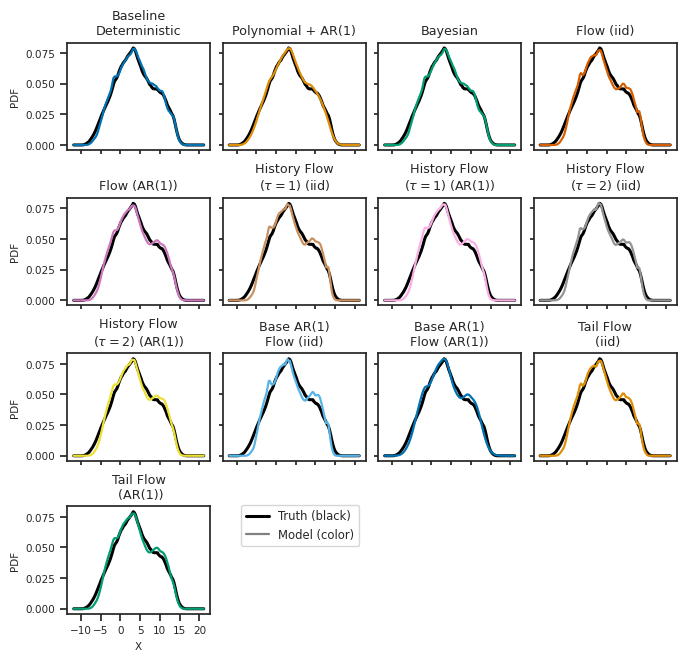

In [22]:
set_model_order(REDUCED_MODEL_ORDER)
fig = plot_precomputed_pdf_histlines_grid(
    plot_df=plot_df,
    truth_source="truth",
    models_to_plot=REDUCED_MODEL_ORDER,
    ncols=4,
    figsize=(TEXT_WIDTH, 6.5),
    bbox_to_anchor=(0.34, 0.24),
    legend_cols=1,
    title_line_breaks=True,
)
plt.show()
fig.savefig(
    paper_figures_dir / "pdf_grid.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)
# reset model
set_model_order(MODEL_ORDER_DEFAULT)

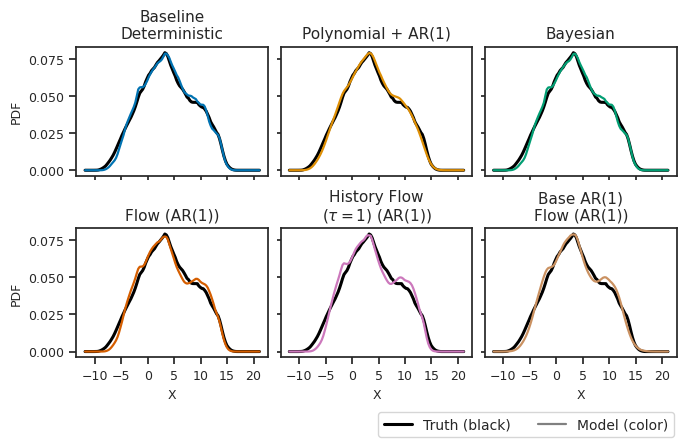

In [23]:
set_model_order(REDUCED_MODEL_ORDER_SELECTED)
show_legend = True
fig = plot_precomputed_pdf_histlines_grid(
    plot_df=plot_df,
    truth_source="truth",
    models_to_plot=REDUCED_MODEL_ORDER_SELECTED,
    ncols=3,
    figsize=(TEXT_WIDTH, 4),
    bbox_to_anchor=(1.0, -0.0),
    legend_cols=2,
    legend_loc="upper right",
    title_line_breaks=True,
    which_base_width="column",
    show_legend=show_legend,
)
plt.show()
legend_str = "_wo_legend" if not show_legend else ""
fig.savefig(
    paper_figures_dir / f"pdf_grid_selected{legend_str}.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)
# reset model
set_model_order(MODEL_ORDER_DEFAULT)

## Density statistics

In [24]:
def hellinger_distance_hist(x_true, x_gcm, bins=100, data_range=None):
    """
    Hellinger distance between two 1D distributions using shared histogram bins.
    x_true, x_gcm: 1D arrays of samples
    bins: int or sequence of bin edges
    data_range: (min, max) for bins (optional)
    """
    x_true = np.asarray(x_true).ravel()
    x_gcm = np.asarray(x_gcm).ravel()
    x_true = x_true[np.isfinite(x_true)]
    x_gcm = x_gcm[np.isfinite(x_gcm)]

    if x_true.size == 0 or x_gcm.size == 0:
        return np.nan

    # Shared data range
    if data_range is None:
        xmin = min(np.min(x_true), np.min(x_gcm))
        xmax = max(np.max(x_true), np.max(x_gcm))
        data_range = (xmin, xmax)

    # Shared bin counts (do not use density=True but normalize manually)
    p, edges = np.histogram(x_true, bins=bins, density=True, range=data_range)
    q, _ = np.histogram(x_gcm, bins=edges, density=True)

    widths = np.diff(edges)

    # Continous Hellinger distance approximation as Riemann sum
    H = np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2 * widths))

    return H

In [25]:
def ks_statistic_2samp(x_true, x_gcm):
    """
    Kolmogorov–Smirnov statistic (two-sample) between two 1D sample arrays.
    Returns: (D, pvalue)
    """
    x_true = np.asarray(x_true).ravel()
    x_gcm = np.asarray(x_gcm).ravel()

    x_true = x_true[np.isfinite(x_true)]
    x_gcm = x_gcm[np.isfinite(x_gcm)]

    if x_true.size == 0 or x_gcm.size == 0:
        return np.nan, np.nan

    res = ks_2samp(x_true, x_gcm, alternative="two-sided", mode="auto")
    return float(res.statistic), float(res.pvalue)


In [26]:
def compute_statistics_df(
    df, bins=100, data_range=None, truth_source="truth", compute_ks=True
):
    """
    df: sample df with columns: source, label, noise_type, ar_oder, delta_t, x
    returns: hell_df with columns: source, label, noise_type, ar_oder, delta_t, hellinger
    """
    rows = []
    truth_source_l = str(truth_source).lower()

    # find truth
    truth_mask = df["source"].astype(str).str.lower().eq(truth_source_l)
    if not truth_mask.any():
        return pd.DataFrame(
            columns=[
                "source",
                "label",
                "noise_type",
                "ar_order",
                "delta_t",
                "hellinger",
                "ks_stat",
                "ks_pvalue",
            ]
        )

    truth_row = df.loc[truth_mask].iloc[0]
    x_true = flatten_x(truth_row["x"])

    # compare all non-truth models to truth
    for _, r in df.loc[~truth_mask].iterrows():
        x_model = flatten_x(r["x"])
        H = hellinger_distance_hist(
            x_true,
            x_model,
            bins=bins,
            data_range=data_range,
        )
        if compute_ks:
            D, p = ks_statistic_2samp(x_true, x_model)
        else:
            D, p = np.nan, np.nan

        rows.append(
            {
                "source": r["source"],
                "noise_type": r["noise_type"],
                "ar_order": r["ar_order"],
                "delta_t": r["delta_t"],
                "hellinger": H,
                "ks_stat": D,
                "ks_pvalue": p,
            }
        )
        del x_model

    del x_true
    return pd.DataFrame(rows)

In [27]:
t0 = time.perf_counter()
compute_ks = True  # KS is very slow, so optionally disable for faster runs
stats_df = compute_statistics_df(
    data_df, bins=100, truth_source="truth", compute_ks=compute_ks
)
elapsed = time.perf_counter() - t0
print(f"Stats done in {_format_mmss(elapsed)}")

stats_df.to_parquet(output_dir / "precomputed_stats.parquet")
print("Saved precomputed statistics to parquet.")

Stats done in 09:55
Saved precomputed statistics to parquet.


In [36]:
# Load precomputed data from parquet
# stats_df = pd.read_parquet(output_dir / "precomputed_stats.parquet")
# print("Loaded precomputed statistics from parquet.")
# compute_ks = True if "ks_stat" in stats_df.columns else False

In [37]:
def select_stats_rows_for_order_key(
    sub_models: pd.DataFrame, order_key: str
) -> pd.DataFrame:
    """
    Select rows from stats_df that match an order_key from MODEL_ORDER,
    using model_order_to_query(order_key) = (model, noise_type, ar_order, delta_t).

    Assumes stats_df rows store:
      - source (string) == model_base
      - noise_type (string or None/NaN)
      - ar_order (numeric or None/NaN)
      - delta_t (numeric or None/NaN)
    """
    model, noise, ar_order, delta_t = model_order_to_query(order_key)
    m = sub_models

    # Compare None against NaN in dataframe
    noise_mask = m["noise_type"].isna() if noise is None else (m["noise_type"] == noise)

    if ar_order is None:
        ar_mask = m["ar_order"].isna()
    else:
        ar_mask = np.isclose(
            m["ar_order"].astype(float), float(ar_order), equal_nan=False
        )

    if delta_t is None:
        dt_mask = m["delta_t"].isna()
    else:
        dt_mask = np.isclose(
            m["delta_t"].astype(float), float(delta_t), equal_nan=False
        )

    mask = (m["source"] == model) & noise_mask & ar_mask & dt_mask
    return m.loc[mask].copy()


In [38]:
def plot_hellinger(stats_df: pd.DataFrame, models_to_plot=None, figsize=(10, 6)):
    """
    Plot-only: expects computed hellinger stat in stats_df.

    Ordering and coloring follow MODEL_ORDER.
    models_to_plot semantics:
      - None -> all keys in MODEL_ORDER
      - iterable can contain:
          * order_key strings
          * model base names (compared to model returned by model_order_to_query)
    """
    sns.set_theme(style="white")

    if stats_df.empty:
        raise ValueError("stats_df is empty")

    sub = stats_df.copy()

    # --- determine which order_keys to include ---
    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)

    if not keys:
        raise ValueError("No matching models_to_plot found")

    # --- collect rows in MODEL_ORDER ---
    ordered = []
    for order_key in keys:
        sub_k = select_stats_rows_for_order_key(sub, order_key)
        if not sub_k.empty:
            ordered.append((order_key, sub_k.iloc[0]))

    if not ordered:
        raise ValueError("No matching rows found in stats_df for the selected models")

    # --- plotting ---
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(ordered))
    y = [row["hellinger"] for _, row in ordered]
    cols = [COLOR_MAP.get(ok, "C0") for ok, _ in ordered]

    ax.scatter(x, y, marker="x", s=60, c=cols)

    labels = []
    for ok, _ in ordered:
        model, noise, ar_order, delta_t = model_order_to_query(ok)
        labels.append(parse_label(model, noise, ar_order, delta_t, line_breaks=False))

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")

    ax.set_ylabel("Hellinger distance to truth")
    ax.set_xlabel("")
    ax.set_title("Hellinger distances")

    ax.tick_params(bottom=False, left=True)
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

    fig.tight_layout()
    return fig

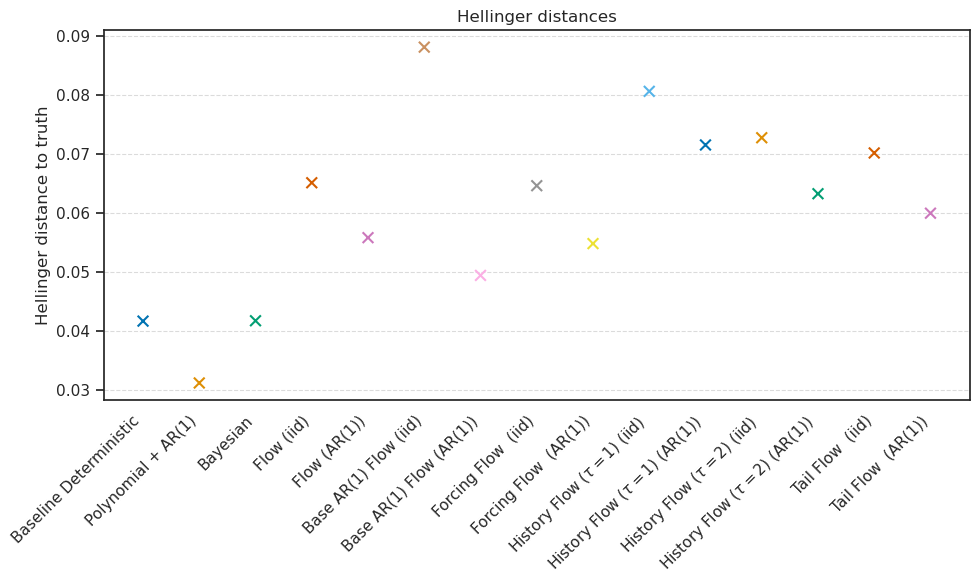

In [39]:
fig = plot_hellinger(stats_df, figsize=(10, 6))
plt.show()
save_plot(fig, figures_dir / "hellinger_distances.pdf")

In [40]:
def plot_kolmogorov_smirnov(
    stats_df: pd.DataFrame,
    models_to_plot=None,
    figsize=(10, 6),
):
    """
    Plot-only: expects computed ks_stat in stats_df.

    Ordering and coloring follow MODEL_ORDER.
    Uses select_stats_rows_for_order_key(...) for matching.

    models_to_plot semantics:
      - None -> all keys in MODEL_ORDER
      - iterable can contain:
          * order_key strings
          * model base names (compared to model returned by model_order_to_query)
    """
    sns.set_theme(style="white")

    if stats_df.empty:
        raise ValueError("stats_df is empty")

    sub = stats_df.copy()

    # --- determine which order_keys to include ---
    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)

    if not keys:
        raise ValueError("No matching models_to_plot found")

    # --- collect rows in MODEL_ORDER ---
    ordered = []
    for order_key in keys:
        sub_k = select_stats_rows_for_order_key(sub, order_key)
        if not sub_k.empty:
            ordered.append((order_key, sub_k.iloc[0]))

    if not ordered:
        raise ValueError("No matching rows found in stats_df for the selected models")

    # --- plotting ---
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(ordered))
    y = [row["ks_stat"] for _, row in ordered]
    cols = [COLOR_MAP.get(ok, "C0") for ok, _ in ordered]

    ax.scatter(x, y, marker="x", s=60, c=cols)

    labels = []
    for ok, _ in ordered:
        model, noise, ar_order, delta_t = model_order_to_query(ok)
        labels.append(parse_label(model, noise, ar_order, delta_t, line_breaks=False))

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")

    ax.set_ylabel("KS test statistic")
    ax.set_xlabel("")
    ax.set_title("Kolmogorov–Smirnov test statistics")

    ax.tick_params(bottom=False, left=True)
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

    fig.tight_layout()
    return fig

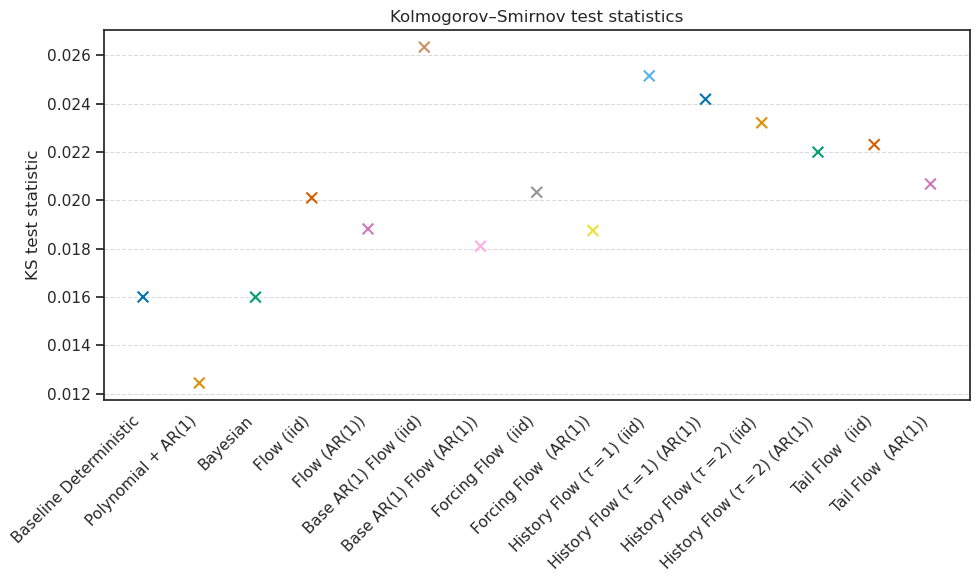

In [41]:
if compute_ks:
    fig = plot_kolmogorov_smirnov(stats_df, figsize=(10, 6))
    plt.show()
    save_plot(
        fig,
        figures_dir / "ks_test_statistics.pdf",
    )

In [42]:
for row in stats_df.itertuples():
    print(
        f"Model: {parse_label(row.source, row.noise_type, row.ar_order, row.delta_t)}"
    )
    print(f"  Hellinger: {row.hellinger:.4f}, KS stat: {row.ks_stat:.4f}")


Model: Baseline Deterministic
  Hellinger: 0.0416, KS stat: 0.0160
Model: Polynomial + AR(1)
  Hellinger: 0.0311, KS stat: 0.0124
Model: Bayesian
  Hellinger: 0.0417, KS stat: 0.0160
Model: Flow (iid)
  Hellinger: 0.0651, KS stat: 0.0201
Model: Flow (AR(1.0))
  Hellinger: 0.0558, KS stat: 0.0188
Model: Base AR(1) Flow (iid)
  Hellinger: 0.0881, KS stat: 0.0263
Model: Base AR(1) Flow (AR(1.0))
  Hellinger: 0.0494, KS stat: 0.0181
Model: History Flow ($\tau = 1$) (iid)
  Hellinger: 0.0806, KS stat: 0.0251
Model: History Flow ($\tau = 2$) (iid)
  Hellinger: 0.0727, KS stat: 0.0232
Model: History Flow ($\tau = 1$) (AR(1.0))
  Hellinger: 0.0715, KS stat: 0.0242
Model: History Flow ($\tau = 2$) (AR(1.0))
  Hellinger: 0.0632, KS stat: 0.0220
Model: Forcing Flow  (iid)
  Hellinger: 0.0646, KS stat: 0.0203
Model: Forcing Flow  (AR(1.0))
  Hellinger: 0.0548, KS stat: 0.0187
Model: Tail Flow  (iid)
  Hellinger: 0.0701, KS stat: 0.0223
Model: Tail Flow  (AR(1.0))
  Hellinger: 0.0599, KS stat: 0.02

## Presentation-ready stats plots

In [43]:
def plot_stats_slides(
    stats_df: pd.DataFrame,
    stat: str,
    models_to_plot=None,
    figsize=(10, 6),
    which_base_width="slide",
):
    if stat not in ["hellinger", "ks_stat"]:
        raise ValueError(
            f"stat '{stat}' not recognized. Must be 'hellinger' or 'ks_stat'."
        )
    if stat == "ks_stat" and "ks_stat" not in stats_df.columns:
        raise ValueError("ks_stat column not found in stats_df")

    rc = get_plot_rc(which_base_width, figsize).copy()
    # overwrite label size for slide
    rc["ytick.labelsize"] = 18

    sns.set_theme(style="white", rc=rc)

    sub = stats_df.copy()

    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)

    ordered = []
    for order_key in keys:
        sub_k = select_stats_rows_for_order_key(sub, order_key)
        if not sub_k.empty:
            ordered.append((order_key, sub_k.iloc[0]))

    if not ordered:
        raise ValueError("No matching rows found")

    rows = []
    for ok, row in ordered:
        model, noise, ar_order, delta_t = model_order_to_query(ok)
        rows.append(
            {
                "order_key": ok,
                "label": parse_label(
                    model, noise, ar_order, delta_t, line_breaks=False
                ),
                stat: row[stat],
                "color": COLOR_MAP.get(ok, "C0"),
            }
        )

    plot_data = (
        pd.DataFrame(rows).sort_values(stat, ascending=True).reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=figsize)

    y = np.arange(len(plot_data))

    ax.hlines(
        y=y,
        xmin=0,
        xmax=plot_data[stat],
        color="0.75",
        linewidth=1.5,
        zorder=1,
    )

    ax.scatter(
        plot_data[stat],
        y,
        s=90,
        c=plot_data["color"],
        marker="x",
        zorder=2,
        linewidth=2.8,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["label"])
    if stat == "hellinger":
        ax.set_xlim(0.0, 0.1)
    else:
        ax.set_xlim(0.0, 0.03)

    stat_label = (
        "Hellinger distance to truth" if stat == "hellinger" else "KS test statistic"
    )
    ax.set_xlabel(stat_label)
    ax.set_ylabel("")

    stat_title = (
        "Hellinger distances"
        if stat == "hellinger"
        else "Kolmogorov–Smirnov test statistics"
    )
    ax.set_title(stat_title, pad=10)

    ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.tick_params(bottom=True, left=False, length=5.5)
    ax.margins(y=0.05)
    sns.despine(left=True, trim=True)

    fig.tight_layout()
    return fig

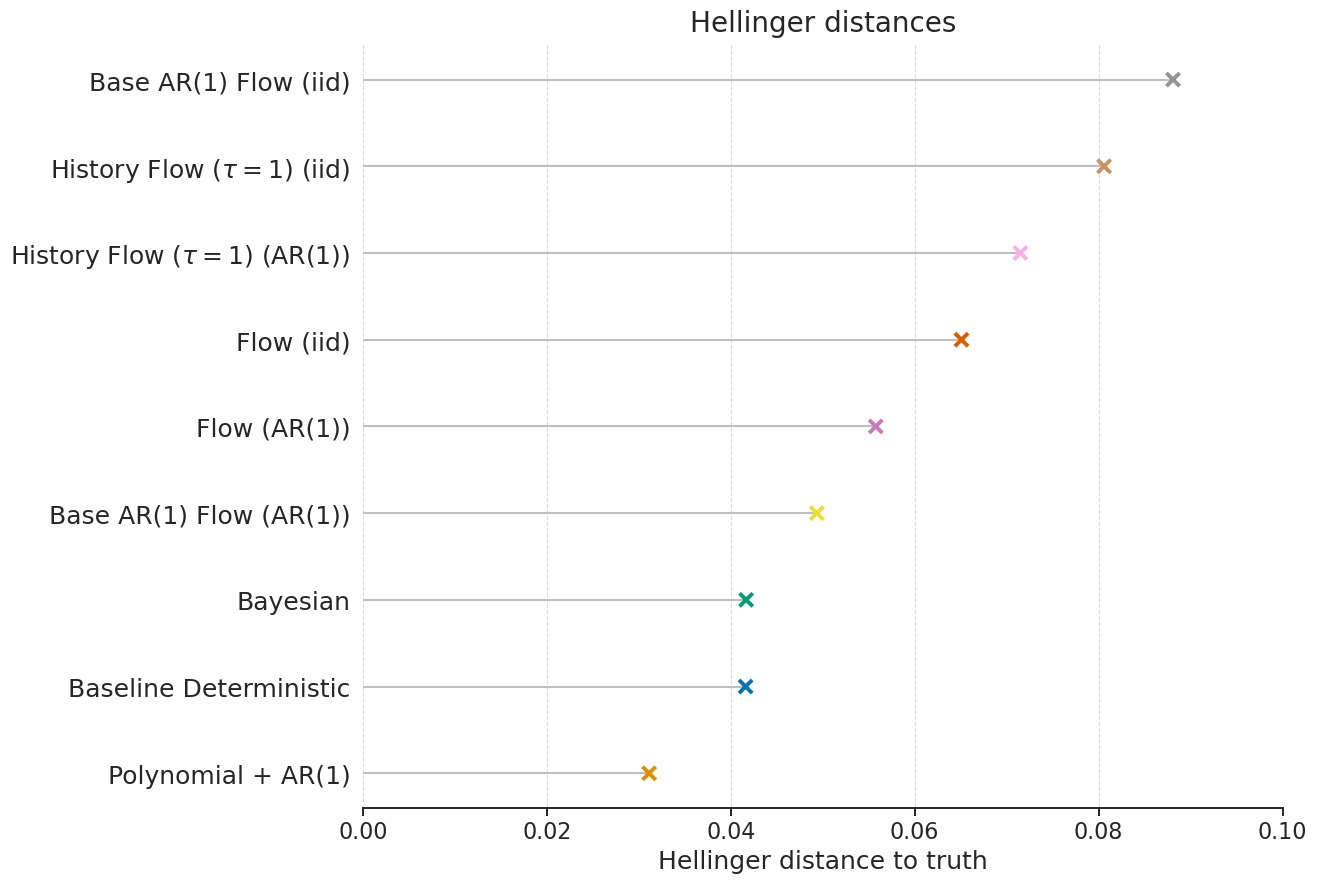

In [44]:
REDUCED_MODEL_ORDER_SLIDES = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-white",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-white",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_ar_base_flow-white",
    "ensemble_gcm_ar_base_flow-ar_p-1",
]
set_model_order(REDUCED_MODEL_ORDER_SLIDES)
stat = "hellinger"
fig = plot_stats_slides(
    stats_df,
    stat=stat,
    models_to_plot=REDUCED_MODEL_ORDER_SLIDES,
    figsize=(SLIDE_WIDTH, 9),
    which_base_width="slide",
)
plt.show()
fig.savefig(
    slides_figures_dir / f"{stat}_distances.png",
    dpi=600,
    bbox_inches="tight",
    format="png",
)
set_model_order(MODEL_ORDER_DEFAULT)

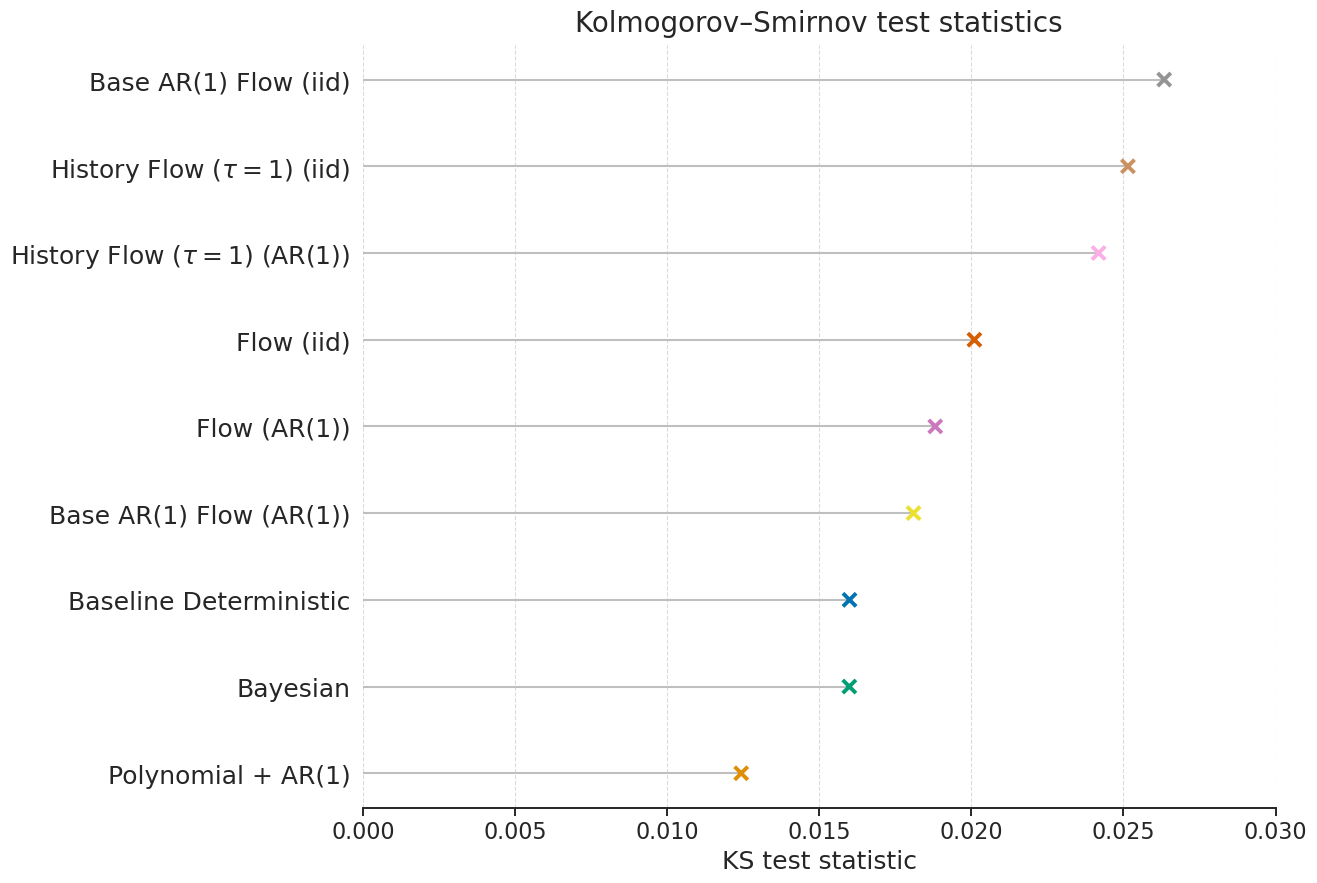

In [45]:
REDUCED_MODEL_ORDER_SLIDES = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-white",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-white",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_ar_base_flow-white",
    "ensemble_gcm_ar_base_flow-ar_p-1",
]
set_model_order(REDUCED_MODEL_ORDER_SLIDES)
stat = "ks_stat"
fig = plot_stats_slides(
    stats_df,
    stat=stat,
    models_to_plot=REDUCED_MODEL_ORDER_SLIDES,
    figsize=(SLIDE_WIDTH, 9),
    which_base_width="slide",
)
plt.show()
fig.savefig(
    slides_figures_dir / f"{stat}_distances.png",
    dpi=600,
    bbox_inches="tight",
    format="png",
)
set_model_order(MODEL_ORDER_DEFAULT)